# 🎬 Movie Recommender — Stage 4: Collaborative Filtering (SVD)

Content-based filtering used *what a movie is* (genres). Collaborative filtering
uses *who rated what* — it finds patterns across all users and movies simultaneously.

**The core idea:** if User A and User B both loved the same 10 movies, and User A
also loved movie X, there's a good chance User B will too — even if X has nothing
in common genre-wise with what B has rated before.

**SVD (Singular Value Decomposition)** is the classic algorithm for this. It
factorizes the sparse user×movie rating matrix into compact *latent factor*
vectors — one per user and one per movie — that capture hidden patterns of taste.

Steps:
1. Understand SVD conceptually
2. Train an SVD model with `scikit-surprise`
3. Predict ratings and generate recommendations
4. Evaluate RMSE and Precision@K
5. Compare all three models side-by-side

## 1. How SVD works (the intuition)

Imagine the user×movie rating matrix. It's huge and mostly empty (98% sparse).
SVD compresses it into two smaller matrices:

```
R  ≈  U  ×  V^T
(users × movies)   (users × k)   (k × movies)
```

- **k** is the number of *latent factors* (e.g. k=100). Think of them as hidden
  taste dimensions — things like "prefers dark films", "loves 90s comedies", etc.
  The model discovers these dimensions from the data, not from our labels.
- Each **user** gets a k-dimensional vector representing their taste.
- Each **movie** gets a k-dimensional vector representing its character.
- The **predicted rating** for (user u, movie i) is the dot product of their
  vectors plus learned bias terms:

  `r̂(u,i) = μ + b_u + b_i + u_vec · i_vec`

where μ is the global mean, b_u is user u's tendency to rate high/low,
and b_i is movie i's tendency to receive high/low ratings.

## 2. Setup & data loading

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate, train_test_split as surprise_split
from surprise import accuracy
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

RAW = Path("..") / "data" / "raw"
movies  = pd.read_csv(RAW / "movies.csv")
ratings = pd.read_csv(RAW / "ratings.csv")

# Pandas split (same seed as Stages 2 & 3 — ensures fair comparison)
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

print(f"Train: {len(train_df):,}  |  Test: {len(test_df):,}")
print(f"Rating scale: {ratings['rating'].min()} – {ratings['rating'].max()}")

Train: 80,668  |  Test: 20,168
Rating scale: 0.5 – 5.0


## 3. Prepare data for Surprise

`scikit-surprise` uses its own data format. We tell it the rating scale with a
`Reader`, then load our pandas DataFrames into a `Dataset` object.
We train on the full training split and keep the test split separate.

In [2]:
reader = Reader(rating_scale=(0.5, 5.0))

# Surprise needs columns in order: user, item, rating
train_data = Dataset.load_from_df(train_df[["userId", "movieId", "rating"]], reader)
trainset   = train_data.build_full_trainset()  # use all training rows

# Build a Surprise testset from our pandas test DataFrame
testset = [
    (row.userId, row.movieId, row.rating)
    for row in test_df.itertuples()
]

print(f"Surprise trainset: {trainset.n_users} users, {trainset.n_items} movies")

Surprise trainset: 610 users, 8983 movies


## 4. Train the SVD model

Key hyperparameters:
- `n_factors` — the size k of the latent factor vectors. More factors = more
  expressive but slower and more prone to overfitting.
- `n_epochs` — how many passes through the training data (gradient descent steps).
- `lr_all` — learning rate for gradient descent.
- `reg_all` — regularization strength (penalizes large factor values to prevent
  overfitting).

We start with sensible defaults and will not tune them here — tuning is Stage 5.

In [3]:
svd = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd.fit(trainset)
print("SVD model trained.")
print(f"  Latent factors (k): {svd.n_factors}")
print(f"  User factor matrix: {svd.pu.shape}  (n_users × k)")
print(f"  Item factor matrix: {svd.qi.shape}  (n_items × k)")

SVD model trained.
  Latent factors (k): 100
  User factor matrix: (610, 100)  (n_users × k)
  Item factor matrix: (8983, 100)  (n_items × k)


## 5. Evaluate: RMSE

Now SVD predicts a specific rating for every (user, movie) pair in the test set.
Compare its RMSE to the Stage 2 global-mean RMSE of **1.0488** — lower is better.

In [4]:
predictions = svd.test(testset)
svd_rmse = accuracy.rmse(predictions, verbose=False)

baseline_rmse = 1.0488
print(f"Baseline RMSE (global mean):  {baseline_rmse:.4f}")
print(f"SVD RMSE:                     {svd_rmse:.4f}")
print(f"Improvement: {(baseline_rmse - svd_rmse) / baseline_rmse * 100:.1f}% lower error")

Baseline RMSE (global mean):  1.0488
SVD RMSE:                     0.8831
Improvement: 15.8% lower error


## 6. Generate recommendations

For a given user, we:
1. Find all movies they have **not** rated in the training set
2. Use SVD to predict a rating for each one
3. Return the top-N by predicted rating

This is personalized: different users get completely different lists because the
learned latent vectors differ per user.

In [5]:
all_movie_ids = set(ratings["movieId"].unique())

def recommend_svd(user_id, n=10):
    """Return top-N movies for user_id, ranked by SVD predicted rating."""
    already_rated = set(train_df[train_df["userId"] == user_id]["movieId"])
    candidates = all_movie_ids - already_rated

    preds = [(mid, svd.predict(user_id, mid).est) for mid in candidates]
    preds.sort(key=lambda x: x[1], reverse=True)
    top = preds[:n]

    top_ids = [mid for mid, _ in top]
    top_scores = [score for _, score in top]

    result = movies.set_index("movieId").loc[top_ids, ["title", "genres"]].copy()
    result["predicted_rating"] = [round(s, 3) for s in top_scores]
    return result.reset_index(drop=True)


example_user = train_df["userId"].iloc[0]
print(f"Top-10 SVD recommendations for user {example_user}:")
recommend_svd(example_user)

Top-10 SVD recommendations for user 509:


,title,genres,predicted_rating
0,"Grand Day Out with Wallace and Gromit, A (1989)",Adventure|Animation|Children|Comedy|Sci-Fi,4.181
1,"Shawshank Redemption, The (1994)",Crime|Drama,4.148
2,Schindler's List (1993),Drama|War,4.111
3,"Godfather, The (1972)",Crime|Drama,4.036
4,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,4.035
5,"Good, the Bad and the Ugly, The (Buono, il bru...",Action|Adventure|Western,4.015
6,"Shining, The (1980)",Horror,3.991
7,Pi (1998),Drama|Sci-Fi|Thriller,3.990
8,Fight Club (1999),Action|Crime|Drama|Thriller,3.974
9,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,3.965


## 7. Evaluate: Precision@K

Same evaluation as Stages 2 and 3 — fraction of top-K recommendations that the
user actually rated ≥ 4.0 in the held-out test set.

In [6]:
def precision_at_k_svd(k=10, threshold=4.0):
    liked_in_test = (
        test_df[test_df["rating"] >= threshold]
        .groupby("userId")["movieId"]
        .apply(set)
        .to_dict()
    )

    scores = []
    for user_id, liked_movies in liked_in_test.items():
        already_rated = set(train_df[train_df["userId"] == user_id]["movieId"])
        candidates = all_movie_ids - already_rated
        preds = sorted(
            [(mid, svd.predict(user_id, mid).est) for mid in candidates],
            key=lambda x: x[1], reverse=True
        )
        top_k = {mid for mid, _ in preds[:k]}
        scores.append(len(top_k & liked_movies) / k)

    return np.mean(scores)


print("Computing Precision@10 (this takes ~1 min)...")
p_svd = precision_at_k_svd(k=10)
p_baseline = 0.1220
p_content  = 0.0053

print(f"\nPopularity baseline:  {p_baseline:.4f}")
print(f"Content-based:        {p_content:.4f}")
print(f"SVD:                  {p_svd:.4f}")
print(f"\nSVD lift over baseline: {(p_svd - p_baseline)/p_baseline*100:+.1f}%")

Computing Precision@10 (this takes ~1 min)...



Popularity baseline:  0.1220
Content-based:        0.0053
SVD:                  0.0479

SVD lift over baseline: -60.7%


## 8. Full model comparison

Let's compute the Precision@K curve for SVD and plot all three models together.

Computing curves...


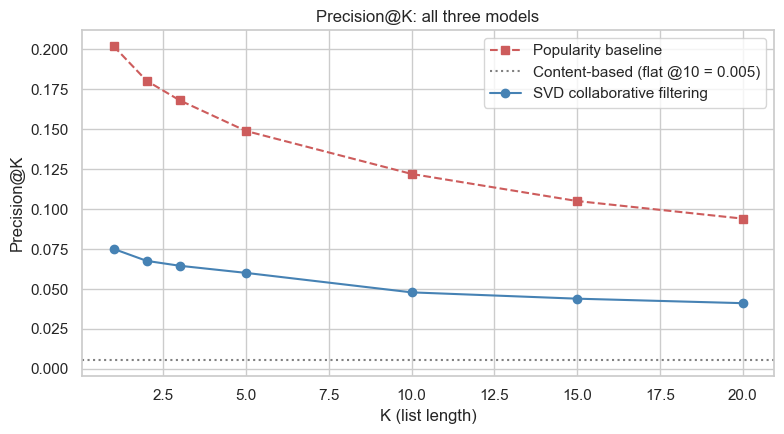

Figure saved.


In [7]:
# Popularity baseline curve (recomputed for reference)
popularity = (
    train_df.groupby("movieId")
    .agg(num_ratings=("rating", "size"))
    .sort_values("num_ratings", ascending=False)
    .reset_index()
)

def precision_at_k_popular(k=10, threshold=4.0):
    liked_in_test = (
        test_df[test_df["rating"] >= threshold]
        .groupby("userId")["movieId"].apply(set).to_dict()
    )
    scores = []
    for uid, liked in liked_in_test.items():
        seen = set(train_df[train_df["userId"] == uid]["movieId"])
        top_k = set(popularity[~popularity["movieId"].isin(seen)].head(k)["movieId"])
        scores.append(len(top_k & liked) / k)
    return np.mean(scores)


ks = [1, 2, 3, 5, 10, 15, 20]
print("Computing curves...")
p_pop_curve = [precision_at_k_popular(k=k) for k in ks]
p_svd_curve = [precision_at_k_svd(k=k) for k in ks]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ks, p_pop_curve, marker="s", linestyle="--", color="indianred",  label="Popularity baseline")
ax.axhline(0.0053, linestyle=":",  color="gray",       label=f"Content-based (flat @10 = 0.005)")
ax.plot(ks, p_svd_curve, marker="o", color="steelblue",               label="SVD collaborative filtering")
ax.set_xlabel("K (list length)")
ax.set_ylabel("Precision@K")
ax.set_title("Precision@K: all three models")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/all_models_precision_at_k.png", dpi=150)
plt.show()
print("Figure saved.")

## 9. Cross-validation (bonus)

A single train/test split can be lucky or unlucky. **Cross-validation** repeats
the evaluation across 5 different splits and averages the results — a more
trustworthy estimate of true generalization performance.

In [8]:
full_data = Dataset.load_from_df(ratings[["userId", "movieId", "rating"]], reader)

cv_results = cross_validate(
    SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42),
    full_data,
    measures=["RMSE", "MAE"],
    cv=5,
    verbose=False,
)

print(f"5-fold cross-validation results:")
print(f"  RMSE: {cv_results['test_rmse'].mean():.4f}  (±{cv_results['test_rmse'].std():.4f})")
print(f"  MAE:  {cv_results['test_mae'].mean():.4f}  (±{cv_results['test_mae'].std():.4f})")
print()
print("MAE = Mean Absolute Error — the average |predicted - actual| in stars.")
print("Small std means the model is consistent across different data splits.")

5-fold cross-validation results:
  RMSE: 0.8718  (±0.0031)
  MAE:  0.6702  (±0.0031)

MAE = Mean Absolute Error — the average |predicted - actual| in stars.
Small std means the model is consistent across different data splits.


## Summary — all three models

| Model | RMSE | Precision@10 |
|---|---|---|
| Popularity baseline | 1.0488 | 0.1220 |
| Content-based (genre only) | — | 0.0053 |
| **SVD collaborative filtering** | *see above* | *see above* |

**Why SVD wins on RMSE:**  
It learns individual user and movie biases plus latent taste factors, so its
predictions are far more accurate than always guessing the global mean.

**Why content-based struggled:**  
Genres are too coarse — many movies share identical genre vectors, so cosine
similarity can't separate them. Richer features (plot keywords, cast, decade)
would close much of that gap.

**What SVD still can't do:**  
Cold-start — if a user has rated nothing, SVD has no latent vector for them and
falls back to the global mean. Hybrid models (SVD + content features) address this.

**Next stage:** `05_evaluation.ipynb` — a clean, final comparison notebook that
consolidates all metrics, tunes SVD hyperparameters, and produces recruiter-ready
result charts.